**Drive mount + imports**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import os
import numpy as np

Mounted at /content/drive


**zip extract**

In [ ]:
import zipfile

SOURCE_ZIP = '/content/drive/MyDrive/Thesis /Final /archive.zip'
DEST_PATH = '/content/data'

os.makedirs(DEST_PATH, exist_ok=True)
with zipfile.ZipFile(SOURCE_ZIP, 'r') as z:
    z.extractall(DEST_PATH)

print("Done.")

Done.


**DATA_PATH & split**

In [ ]:
DATA_PATH = '/content/data/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'
classes = ['Normal', 'Cyst', 'Tumor', 'Stone']

!pip install split-folders -q
import splitfolders

splitfolders.ratio(DATA_PATH, output="/content/split_data",
                    seed=42, ratio=(.7, .15, .15))

Copying files: 12446 files [00:11, 1111.82 files/s]


**dataset loaders**

In [ ]:
IMG_SIZE = (224, 224)
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/split_data/train', image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=42)
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/split_data/val', image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/split_data/test', image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 8710 files belonging to 4 classes.
Found 1865 files belonging to 4 classes.
Found 1871 files belonging to 4 classes.
Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']


**augmentation + preprocessing**

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

**class weights**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = []
for _, y in tf.keras.utils.image_dataset_from_directory(
        '/content/split_data/train', image_size=IMG_SIZE, batch_size=BATCH, shuffle=False):
    train_labels.extend(y.numpy())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

Found 8710 files belonging to 4 classes.
{0: np.float64(0.8387904468412943), 1: np.float64(0.6128623698283141), 2: np.float64(2.2611630321910696), 3: np.float64(1.3626408010012516)}


**model define**

In [ ]:
base_model = tf.keras.applications.ResNet50(
    include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**training with class weights:**

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 171s 557ms/step - accuracy: 0.6589 - loss: 0.8562 - val_accuracy: 0.7694 - val_loss: 0.6053
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 145s 529ms/step - accuracy: 0.8017 - loss: 0.5208 - val_accuracy: 0.8461 - val_loss: 0.4237
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 238s 663ms/step - accuracy: 0.8373 - loss: 0.4258 - val_accuracy: 0.8241 - val_loss: 0.4585
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 172s 630ms/step - accuracy: 0.8615 - loss: 0.3727 - val_accuracy: 0.8611 - val_loss: 0.3668
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 176s 537ms/step - accuracy: 0.8729 - loss: 0.3435 - val_accuracy: 0.8381 - val_loss: 0.4258
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 199s 525ms/step - accuracy: 0.8796 - loss: 0.3234 - val_accuracy: 0.8601 - val_loss: 0.3738
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 145s 529ms/step - accuracy: 0.8840 - loss: 0.3051 - val_accuracy: 0.8627 - val_loss: 0.3594
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 146s 528ms/step - accuracy: 0.8871 -

**Training curve plot**

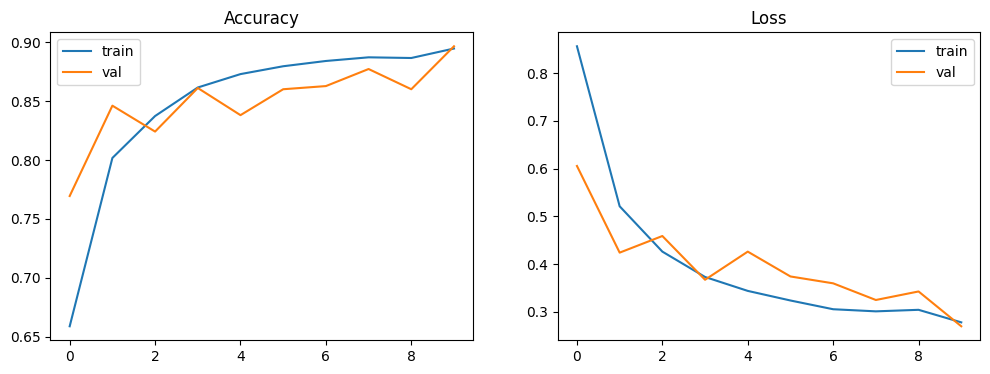

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()
plt.savefig('/content/training_curves_classweight.png', dpi=150)
plt.show()

**Test set evaluate + classification report**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

loss, acc = model.evaluate(test_ds)
print(f'Test accuracy: {acc:.4f}, Test loss: {loss:.4f}')

y_true, y_pred = [], []
for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 367ms/step - accuracy: 0.8915 - loss: 0.2731
Test accuracy: 0.8915, Test loss: 0.2731
              precision    recall  f1-score   support

        Cyst       0.88      0.99      0.93       557
      Normal       0.98      0.86      0.91       763
       Stone       0.69      0.81      0.75       208
       Tumor       0.89      0.86      0.88       343

    accuracy                           0.89      1871
   macro avg       0.86      0.88      0.87      1871
weighted avg       0.90      0.89      0.89      1871

[[550   0   5   2]
 [  9 653  66  35]
 [ 37   2 169   0]
 [ 28  14   5 296]]


**Model save**

In [ ]:
model.save('/content/drive/MyDrive/Thesis /Final /resnet50_kidney_classweighted.keras')
print("Model saved!")

Model saved!


**Grad-CAM Explainability: Locating ResNet50's Last Convolutional Layer**

In [ ]:
for layer in model.get_layer('resnet50').layers[-10:]:
    print(layer.name, layer.output.shape)

conv5_block3_1_conv (None, 7, 7, 512)
conv5_block3_1_bn (None, 7, 7, 512)
conv5_block3_1_relu (None, 7, 7, 512)
conv5_block3_2_conv (None, 7, 7, 512)
conv5_block3_2_bn (None, 7, 7, 512)
conv5_block3_2_relu (None, 7, 7, 512)
conv5_block3_3_conv (None, 7, 7, 2048)
conv5_block3_3_bn (None, 7, 7, 2048)
conv5_block3_add (None, 7, 7, 2048)
conv5_block3_out (None, 7, 7, 2048)


**Grad-CAM heatmap function**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out"):
    resnet_base = model.get_layer('resnet50')
    grad_model = tf.keras.models.Model(
        inputs=resnet_base.input,
        outputs=[resnet_base.get_layer(last_conv_layer_name).output, resnet_base.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, resnet_features = grad_model(img_array)
        # pass resnet output through the rest of the model (pooling, dropout, dense)
        x = model.get_layer('global_average_pooling2d')(resnet_features)
        x = model.get_layer('dropout')(x)
        predictions = model.get_layer('dense')(x)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), class_idx.numpy()

**Grad-CAM Overlay Function + Sample Visualization (One Fixed Image per Class)**

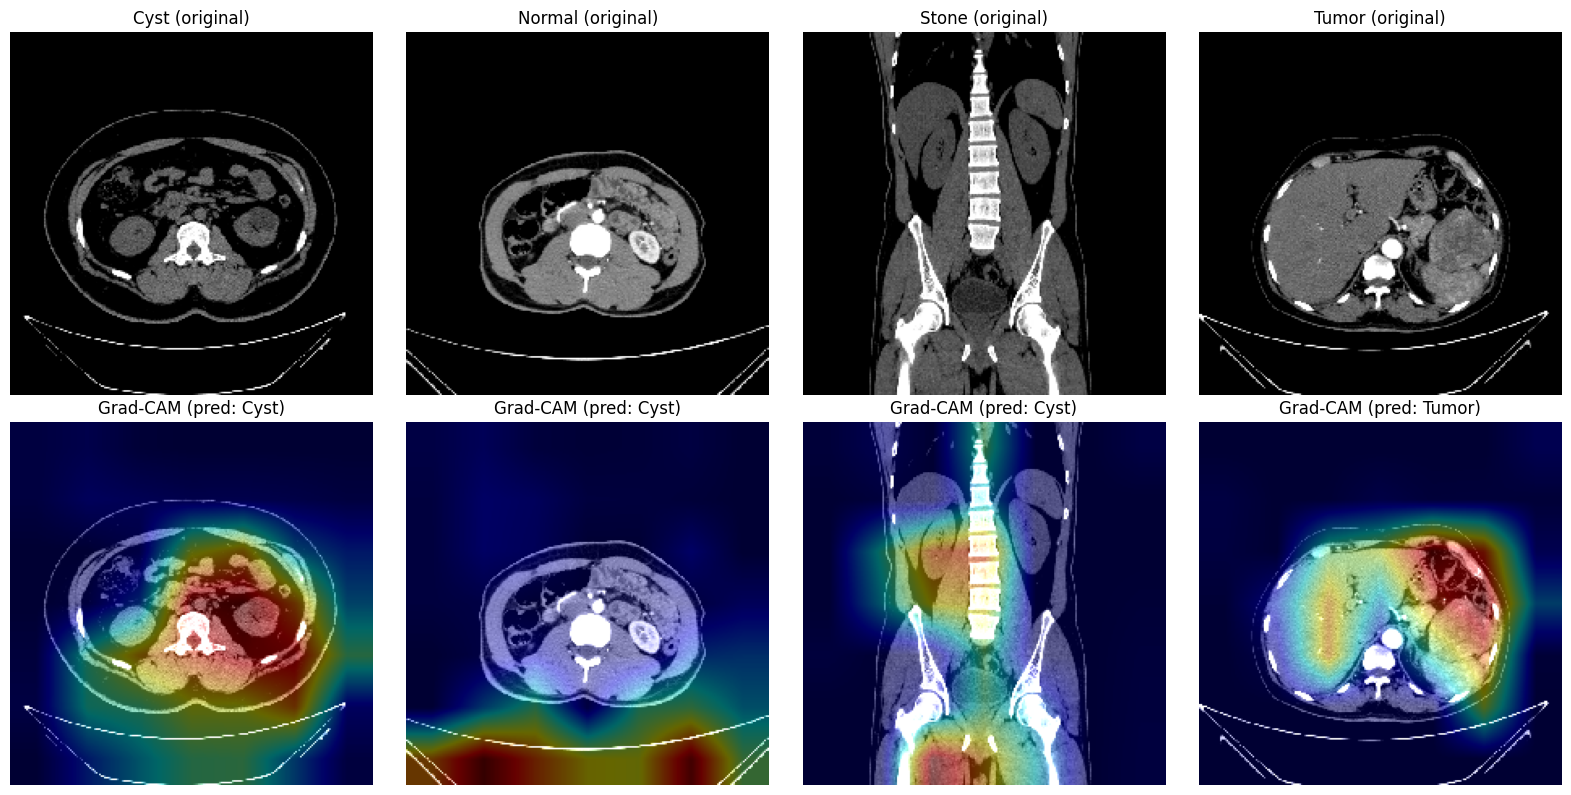

In [ ]:
def display_gradcam(img_array_raw, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_array_raw.shape[1], img_array_raw.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = heatmap_colored * alpha + img_array_raw
    superimposed = np.uint8(np.clip(superimposed, 0, 255))
    return superimposed

# Pick one test image per class and visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, cls in enumerate(class_names):
    cls_path = os.path.join('/content/split_data/test', cls)
    sample_file = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, sample_file)

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array_raw = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array_raw, axis=0)
    img_array_preprocessed = preprocess_input(img_array.copy())

    heatmap, pred_idx = make_gradcam_heatmap(img_array_preprocessed, model)
    overlay = display_gradcam(img_array_raw, heatmap)

    axes[0, i].imshow(img_array_raw.astype('uint8'))
    axes[0, i].set_title(f'{cls} (original)')
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f'Grad-CAM (pred: {class_names[pred_idx]})')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/content/gradcam_samples.png', dpi=150)
plt.show()

**Grad-CAM on Random Samples per Class**

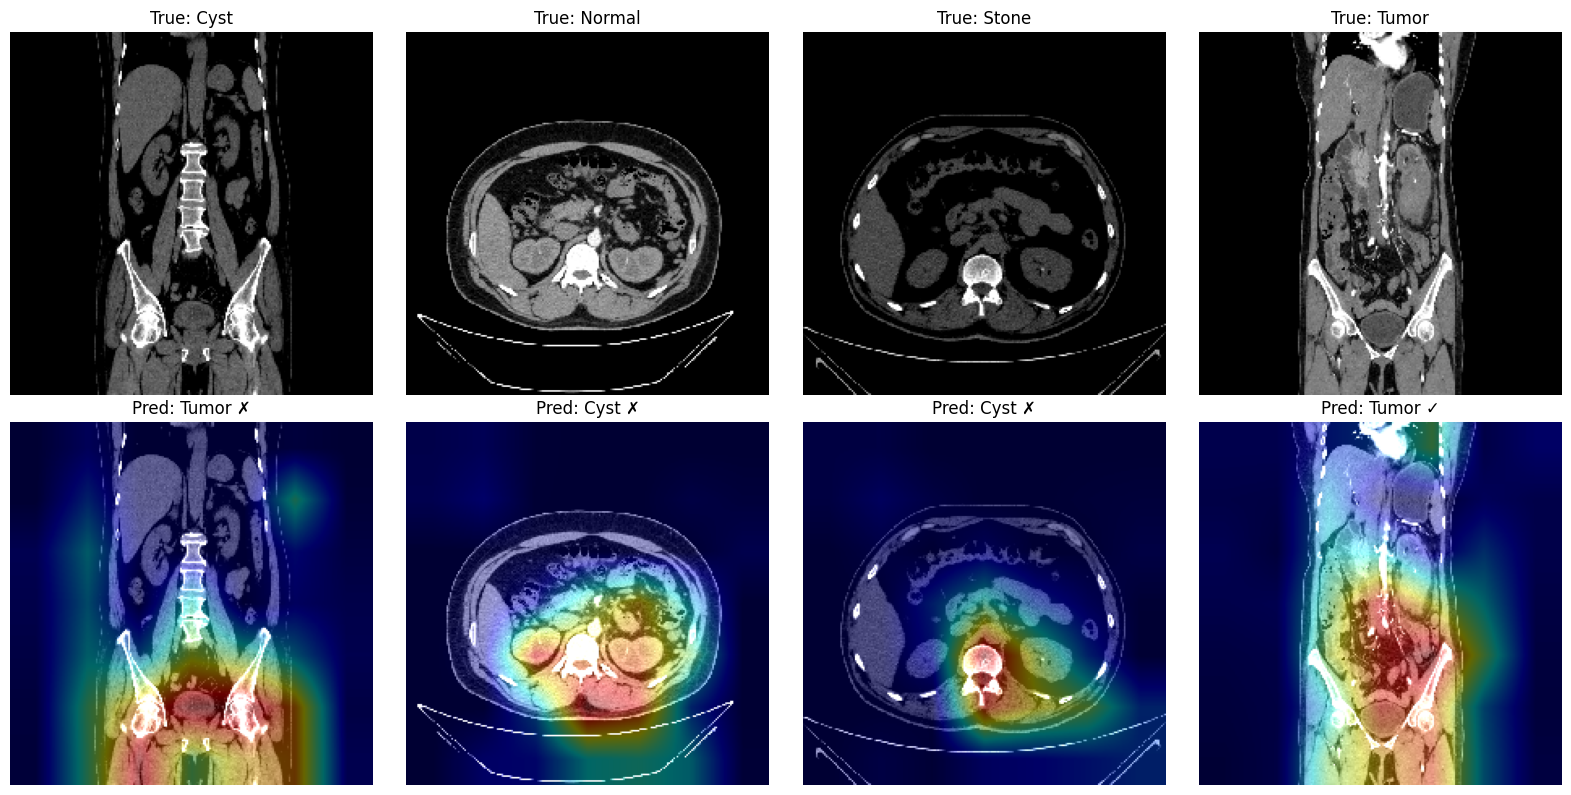

In [ ]:
import random
random.seed(1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, cls in enumerate(class_names):
    cls_path = os.path.join('/content/split_data/test', cls)
    sample_file = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, sample_file)

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array_raw = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array_raw, axis=0)
    img_array_preprocessed = preprocess_input(img_array.copy())

    heatmap, pred_idx = make_gradcam_heatmap(img_array_preprocessed, model)
    overlay = display_gradcam(img_array_raw, heatmap)

    correct = "✓" if class_names[pred_idx] == cls else "✗"
    axes[0, i].imshow(img_array_raw.astype('uint8'))
    axes[0, i].set_title(f'True: {cls}')
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f'Pred: {class_names[pred_idx]} {correct}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/content/gradcam_random_samples.png', dpi=150)
plt.show()

**Extended Grad-CAM Comparison (3 Random Samples per Class)**

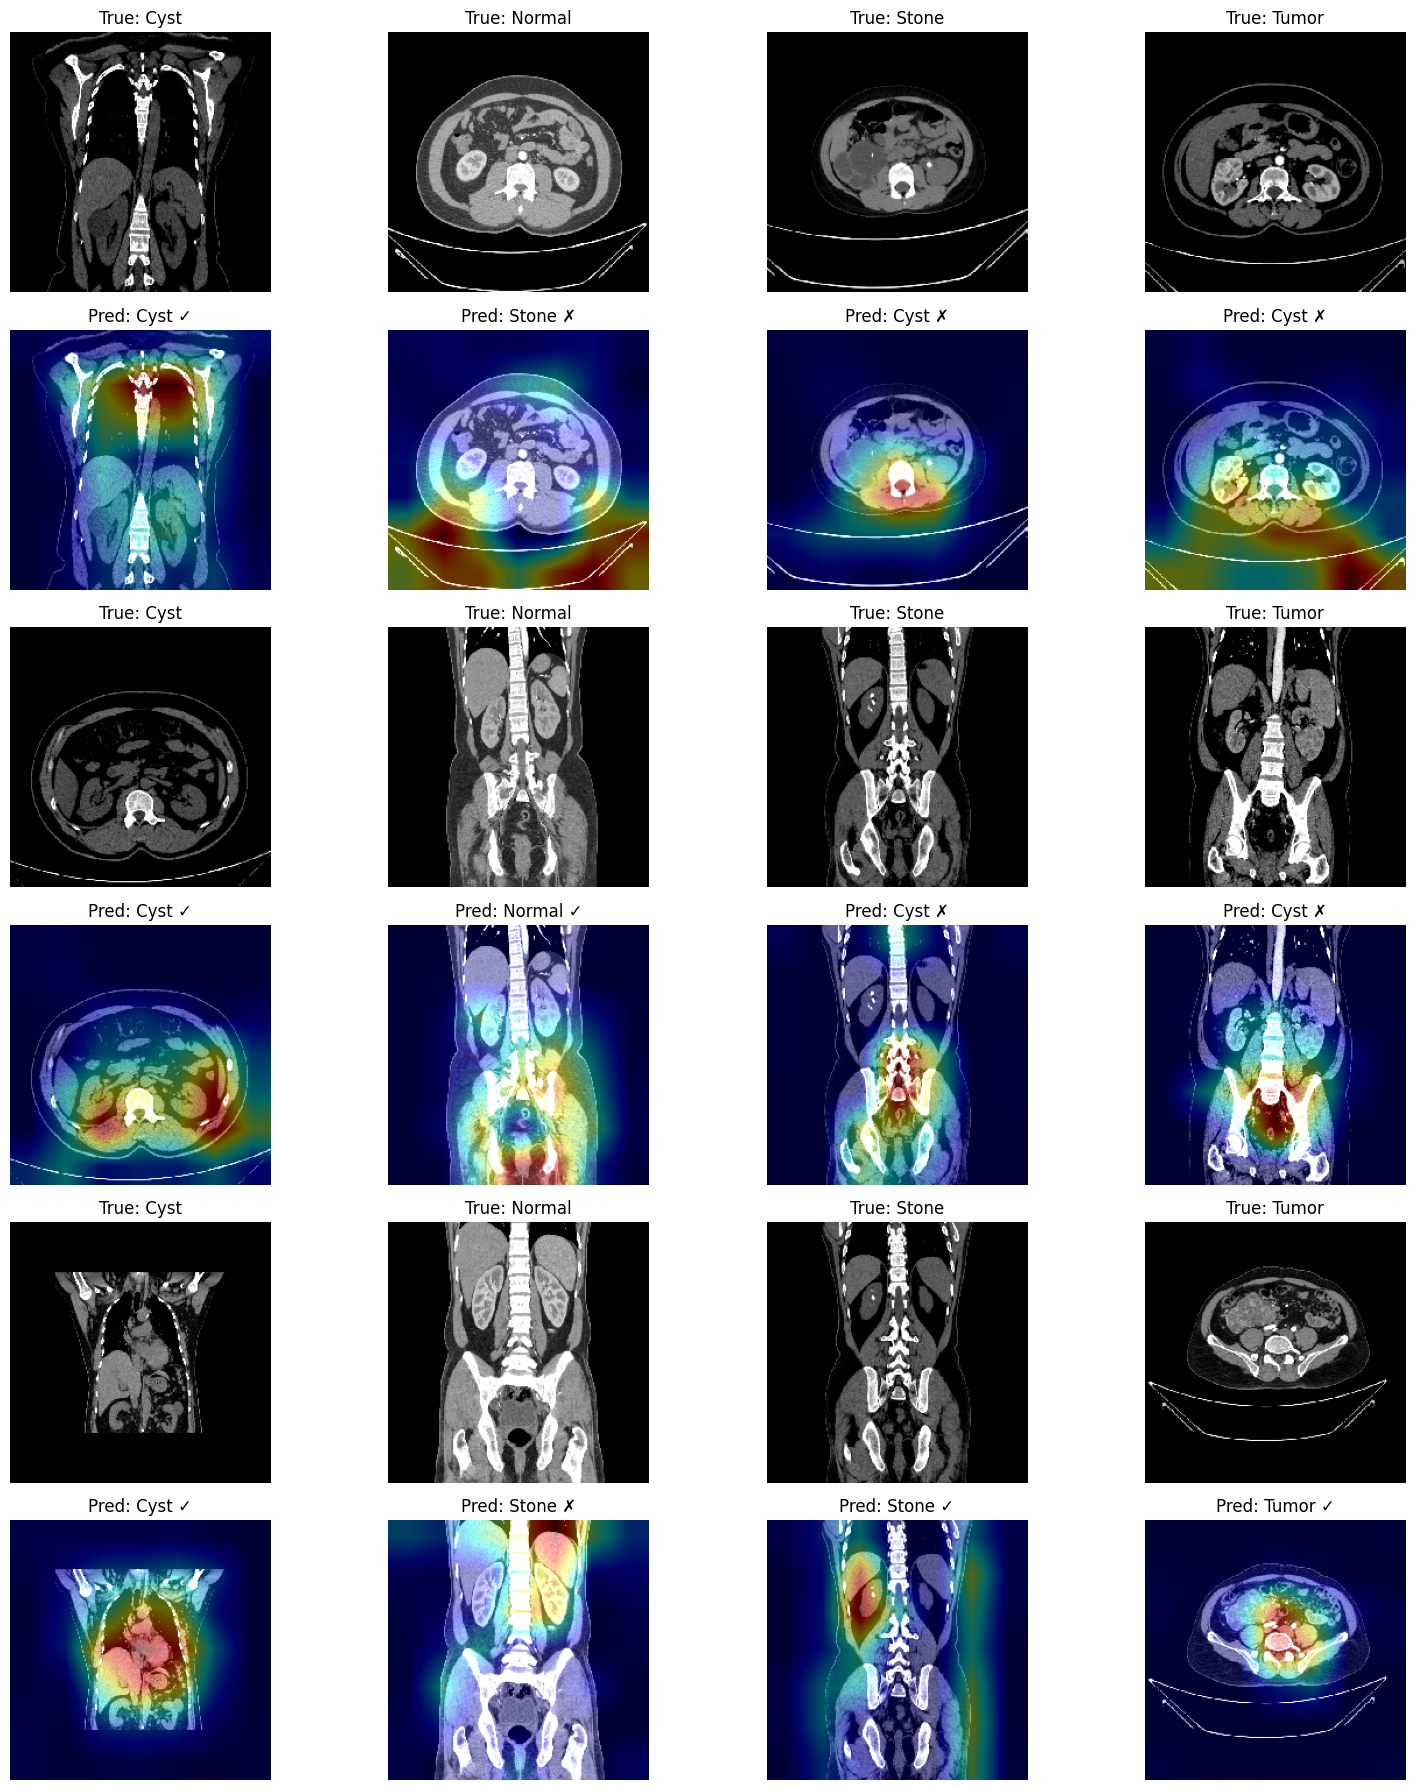

In [ ]:
import random
random.seed(7)

n_per_class = 3
fig, axes = plt.subplots(2 * n_per_class, 4, figsize=(16, 6 * n_per_class))

for i, cls in enumerate(class_names):
    cls_path = os.path.join('/content/split_data/test', cls)
    samples = random.sample(os.listdir(cls_path), n_per_class)

    for j, sample_file in enumerate(samples):
        img_path = os.path.join(cls_path, sample_file)
        img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        img_array_raw = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array_raw, axis=0)
        img_array_preprocessed = preprocess_input(img_array.copy())

        heatmap, pred_idx = make_gradcam_heatmap(img_array_preprocessed, model)
        overlay = display_gradcam(img_array_raw, heatmap)

        correct = "✓" if class_names[pred_idx] == cls else "✗"
        row = j * 2
        axes[row, i].imshow(img_array_raw.astype('uint8'))
        axes[row, i].set_title(f'True: {cls}')
        axes[row, i].axis('off')

        axes[row + 1, i].imshow(overlay)
        axes[row + 1, i].set_title(f'Pred: {class_names[pred_idx]} {correct}')
        axes[row + 1, i].axis('off')

plt.tight_layout()
plt.savefig('/content/gradcam_extended_samples.png', dpi=150)
plt.show()

**Error Analysis: Identifying Misclassified Test Images**

In [ ]:
test_ds_ordered = tf.keras.utils.image_dataset_from_directory(
    '/content/split_data/test', image_size=IMG_SIZE, batch_size=BATCH,
    shuffle=False, interpolation='bilinear'
)
class_names_check = test_ds_ordered.class_names
print(class_names_check)

file_paths = test_ds_ordered.file_paths  # actual file order used

test_ds_processed = test_ds_ordered.map(lambda x, y: (preprocess_input(x), y))

y_true_all, y_pred_all = [], []
for x, y in test_ds_processed:
    preds = model.predict(x, verbose=0)
    y_true_all.extend(y.numpy())
    y_pred_all.extend(np.argmax(preds, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

misclassified_idx = np.where(y_true_all != y_pred_all)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true_all)}")

stone_to_cyst = [i for i in misclassified_idx if class_names_check[y_true_all[i]]=='Stone' and class_names_check[y_pred_all[i]]=='Cyst']
tumor_to_cyst = [i for i in misclassified_idx if class_names_check[y_true_all[i]]=='Tumor' and class_names_check[y_pred_all[i]]=='Cyst']

print(f"Stone misclassified as Cyst: {len(stone_to_cyst)}")
print(f"Tumor misclassified as Cyst: {len(tumor_to_cyst)}")

Found 1871 files belonging to 4 classes.
['Cyst', 'Normal', 'Stone', 'Tumor']
Total misclassified: 203 out of 1871
Stone misclassified as Cyst: 37
Tumor misclassified as Cyst: 28


**Grad-CAM on Misclassified Samples (Stone→Cyst, Tumor→Cyst)**

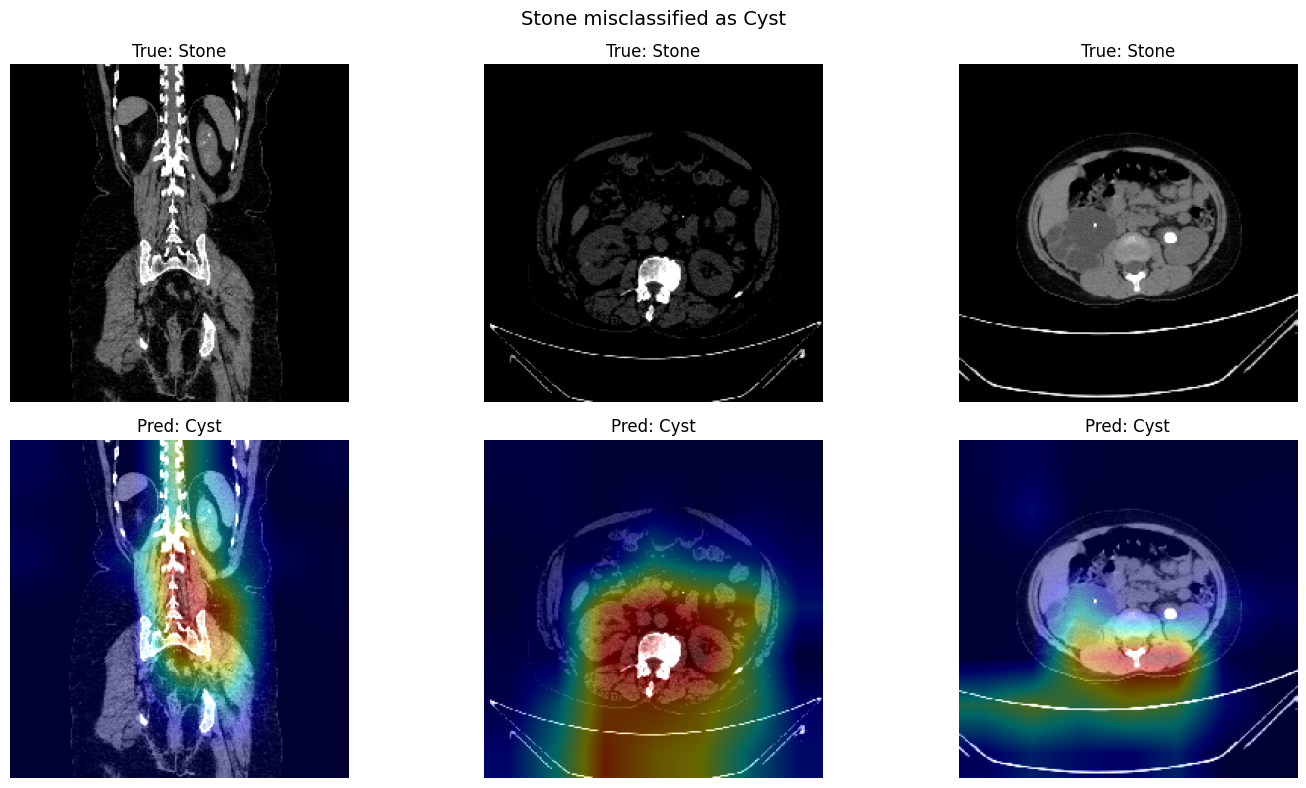

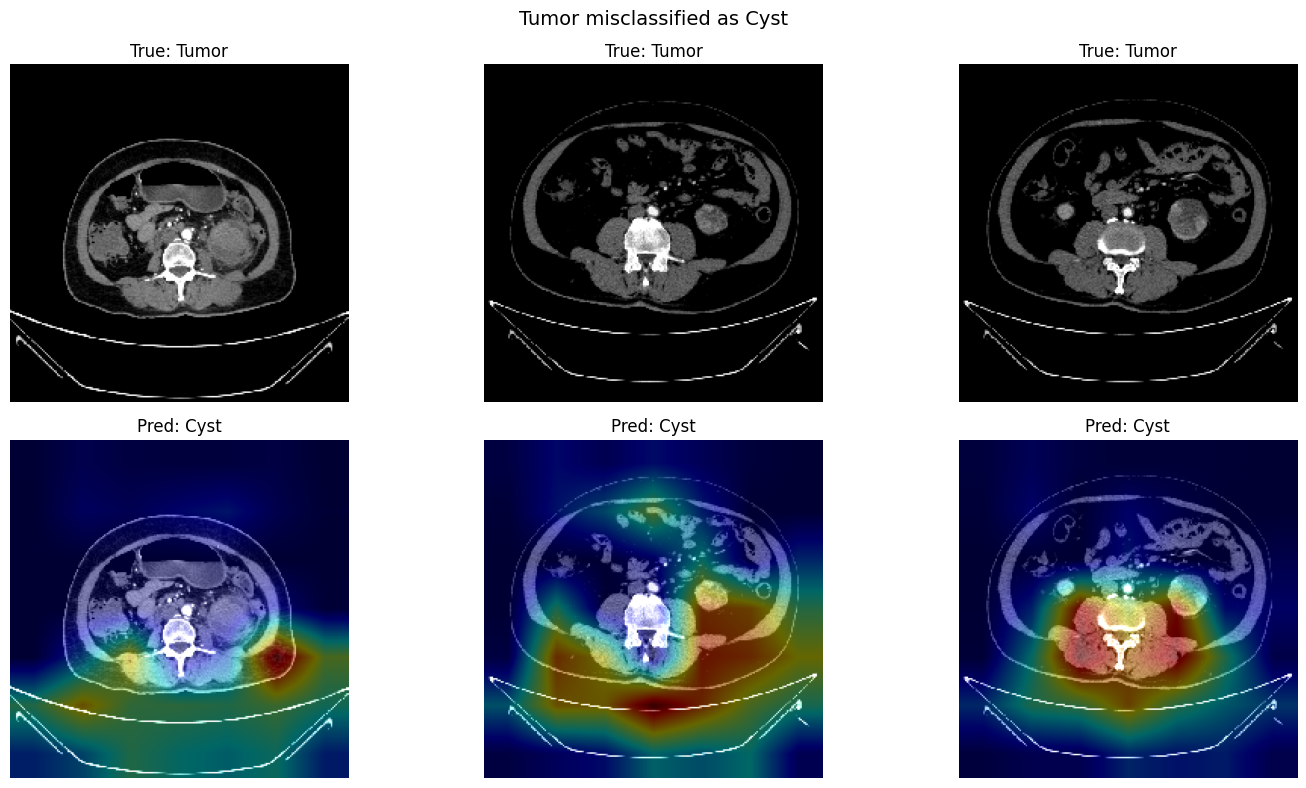

In [ ]:
import random
random.seed(3)

def visualize_misclassified(indices, title, n=3):
    selected = random.sample(indices, min(n, len(indices)))
    fig, axes = plt.subplots(2, len(selected), figsize=(5*len(selected), 8))

    for j, idx in enumerate(selected):
        fpath = file_paths[idx]
        img = tf.keras.utils.load_img(fpath, target_size=(224, 224))
        img_array_raw = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array_raw, axis=0)
        img_array_preprocessed = preprocess_input(img_array.copy())

        heatmap, pred_idx = make_gradcam_heatmap(img_array_preprocessed, model)
        overlay = display_gradcam(img_array_raw, heatmap)

        true_cls = class_names_check[y_true_all[idx]]
        pred_cls = class_names_check[y_pred_all[idx]]

        axes[0, j].imshow(img_array_raw.astype('uint8'))
        axes[0, j].set_title(f'True: {true_cls}')
        axes[0, j].axis('off')

        axes[1, j].imshow(overlay)
        axes[1, j].set_title(f'Pred: {pred_cls}')
        axes[1, j].axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/content/gradcam_{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

visualize_misclassified(stone_to_cyst, "Stone misclassified as Cyst", n=3)
visualize_misclassified(tumor_to_cyst, "Tumor misclassified as Cyst", n=3)